In [299]:
# Importar librerías necesarias
!pip install pandas numpy matplotlib seaborn plotly scikit-learn openpyxl

# Análisis de Rendimiento de Campañas de Marketing Digital

**Objetivo:** Analizar el rendimiento de 10.000 campañas digitales para identificar las combinaciones de plataforma y objetivo más rentables, y generar recomendaciones de optimización de presupuesto.

**Dataset:** Digital Advertising Campaign Performance Dataset (Kaggle)  
**Herramientas:** Python, Pandas, Seaborn, Matplotlib  
**KPIs analizados:** ROAS, CTR, CPC, Conversion Rate, CPA

**Principales hallazgos:**
- TikTok y Facebook son las plataformas con mayor ROAS
- La mejor combinación es TikTok + Lead Generation (ROAS 13.61)
- Finance es la industria más rentable
- LinkedIn y Brand Awareness presentan el menor retorno

In [300]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print("✅ Librerías listas")

✅ Librerías listas


In [301]:
# Cargar el dataset
df = pd.read_csv("tech_advertising_campaigns_dataset (1).csv")

print("✅ Dataset cargado exitosamente")
print(f"Número de filas: {df.shape[0]:,}")
print(f"Número de columnas: {df.shape[1]}")
print("\n--- Primeras 5 filas ---")
df.head()

✅ Dataset cargado exitosamente
Número de filas: 10,000
Número de columnas: 41

--- Primeras 5 filas ---


,campaign_id,campaign_objective,platform,ad_placement,device_type,operating_system,creative_format,creative_size,ad_copy_length,has_call_to_action,creative_emotion,creative_age_days,target_audience_age,target_audience_gender,audience_interest_category,income_bracket,purchase_intent_score,retargeting_flag,start_date,quarter,day_of_week,hour_of_day,campaign_day,quality_score,actual_cpc,impressions,clicks,conversions,ad_spend,revenue,bounce_rate,avg_session_duration_seconds,pages_per_session,industry_vertical,budget_tier,CTR,CPC,conversion_rate,CPA,ROAS,profit
0,CAMP_00001,Lead Generation,Facebook,Search,Mobile,Android,Text,728x90,Short,False,Curiosity,72,45-54,Female,Shoppers,<$50K,Medium,False,2024-03-06,1,Wednesday,18,34,5,2.23,66329,402,2,896.46,289.67,67.75,70,2.00,E-commerce,High,0.61,2.23,0.50,448.23,0.32,-606.79
1,CAMP_00002,Engagement,Facebook,Feed,Mobile,iOS,Image,320x50,Long,True,Neutral,62,65+,Female,Business Professionals,$50K-$100K,Medium,False,2024-01-26,1,Friday,6,22,5,2.48,50094,467,5,1158.16,1728.20,63.73,105,2.74,Finance,Medium,0.93,2.48,1.07,231.63,1.49,570.04
2,CAMP_00003,Conversions,Google Ads,Feed,Tablet,iOS,Video,1920x1080,Short,False,Urgency,79,65+,Male,Tech Enthusiasts,<$50K,High,False,2025-05-15,2,Thursday,1,32,4,3.88,10842,112,6,434.56,2903.26,31.93,149,3.97,Healthcare,Low,1.03,3.88,5.36,72.43,6.68,2468.70
3,CAMP_00004,Conversions,LinkedIn,Search,Desktop,iOS,Carousel,1920x1080,Short,False,Joy,57,35-44,All,Shoppers,<$50K,Low,False,2024-07-21,3,Sunday,7,32,4,8.29,7820,123,3,1019.67,502.28,65.52,147,2.49,Education,Medium,1.57,8.29,2.44,339.89,0.49,-517.39
4,CAMP_00005,Brand Awareness,Facebook,Stories,Mobile,iOS,Image,1920x1080,Short,False,Joy,17,25-34,Female,Students,$100K-$200K,Low,False,2025-03-09,1,Sunday,17,52,7,1.41,21436,302,0,425.82,0.00,68.95,81,3.04,SaaS,Low,1.41,1.41,0.00,0.00,0.00,-425.82


In [302]:
# Información general
print("=== INFORMACIÓN GENERAL DEL DATASET ===")
print(df.info())

=== INFORMACIÓN GENERAL DEL DATASET ===
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 41 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   campaign_id                   10000 non-null  str    
 1   campaign_objective            10000 non-null  str    
 2   platform                      10000 non-null  str    
 3   ad_placement                  10000 non-null  str    
 4   device_type                   10000 non-null  str    
 5   operating_system              10000 non-null  str    
 6   creative_format               10000 non-null  str    
 7   creative_size                 10000 non-null  str    
 8   ad_copy_length                10000 non-null  str    
 9   has_call_to_action            10000 non-null  bool   
 10  creative_emotion              10000 non-null  str    
 11  creative_age_days             10000 non-null  int64  
 12  target_audience_age           10

In [303]:
# Estadísticas de las columnas numéricas
print("=== ESTADÍSTICAS DESCRIPTIVAS ===")
df.describe()

=== ESTADÍSTICAS DESCRIPTIVAS ===


,creative_age_days,quarter,hour_of_day,campaign_day,quality_score,actual_cpc,impressions,clicks,conversions,ad_spend,revenue,bounce_rate,avg_session_duration_seconds,pages_per_session,CTR,CPC,conversion_rate,CPA,ROAS,profit
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,45.37,2.42,11.48,45.43,5.53,3.29,70539.22,1526.44,65.57,4345.57,28415.77,52.53,100.96,3.11,2.31,3.29,3.64,190.90,7.52,24070.20
std,26.17,1.13,6.93,26.07,1.55,2.45,91339.73,2412.16,183.40,6917.48,89284.61,17.71,46.54,1.37,1.57,2.45,4.35,295.61,14.99,86416.10
min,1.00,1.00,0.00,1.00,1.00,0.30,5000.00,10.00,0.00,8.69,0.00,10.00,10.00,1.00,0.10,0.30,0.00,0.00,0.00,-36939.84
25%,22.00,1.00,5.00,23.00,4.00,1.51,16958.50,290.00,5.00,666.31,1608.91,40.09,68.00,2.16,1.17,1.51,1.00,40.64,1.20,209.48
50%,45.00,2.00,12.00,45.00,6.00,2.43,37469.50,718.00,16.00,1895.67,6099.24,53.58,100.00,2.83,1.92,2.43,2.17,99.46,3.15,3302.53
75%,68.00,3.00,18.00,68.00,7.00,4.53,83213.75,1746.00,55.00,4996.16,22165.82,65.47,132.00,3.74,3.02,4.53,4.49,225.46,7.95,16641.88
max,90.00,4.00,23.00,90.00,10.00,16.03,500000.00,40000.00,5384.00,49999.68,2800397.43,90.00,277.00,8.51,8.00,16.03,25.00,6379.94,487.30,2750397.93


In [304]:
# Nombres de todas las columnas
print("=== COLUMNAS DEL DATASET ===")
print(df.columns.tolist())

=== COLUMNAS DEL DATASET ===
['campaign_id', 'campaign_objective', 'platform', 'ad_placement', 'device_type', 'operating_system', 'creative_format', 'creative_size', 'ad_copy_length', 'has_call_to_action', 'creative_emotion', 'creative_age_days', 'target_audience_age', 'target_audience_gender', 'audience_interest_category', 'income_bracket', 'purchase_intent_score', 'retargeting_flag', 'start_date', 'quarter', 'day_of_week', 'hour_of_day', 'campaign_day', 'quality_score', 'actual_cpc', 'impressions', 'clicks', 'conversions', 'ad_spend', 'revenue', 'bounce_rate', 'avg_session_duration_seconds', 'pages_per_session', 'industry_vertical', 'budget_tier', 'CTR', 'CPC', 'conversion_rate', 'CPA', 'ROAS', 'profit']


In [305]:
# Valores faltantes
print("=== VALORES NULOS POR COLUMNA ===")
nulos = df.isnull().sum()
print(nulos[nulos > 0] if nulos.sum() > 0 else "¡No hay valores nulos!")

=== VALORES NULOS POR COLUMNA ===
¡No hay valores nulos!


In [306]:
# Vista rápida de los datos
print("=== MUESTRA DE DATOS ===")
df.head(10)

=== MUESTRA DE DATOS ===


,campaign_id,campaign_objective,platform,ad_placement,device_type,operating_system,creative_format,creative_size,ad_copy_length,has_call_to_action,creative_emotion,creative_age_days,target_audience_age,target_audience_gender,audience_interest_category,income_bracket,purchase_intent_score,retargeting_flag,start_date,quarter,day_of_week,hour_of_day,campaign_day,quality_score,actual_cpc,impressions,clicks,conversions,ad_spend,revenue,bounce_rate,avg_session_duration_seconds,pages_per_session,industry_vertical,budget_tier,CTR,CPC,conversion_rate,CPA,ROAS,profit
0,CAMP_00001,Lead Generation,Facebook,Search,Mobile,Android,Text,728x90,Short,False,Curiosity,72,45-54,Female,Shoppers,<$50K,Medium,False,2024-03-06,1,Wednesday,18,34,5,2.23,66329,402,2,896.46,289.67,67.75,70,2.00,E-commerce,High,0.61,2.23,0.50,448.23,0.32,-606.79
1,CAMP_00002,Engagement,Facebook,Feed,Mobile,iOS,Image,320x50,Long,True,Neutral,62,65+,Female,Business Professionals,$50K-$100K,Medium,False,2024-01-26,1,Friday,6,22,5,2.48,50094,467,5,1158.16,1728.20,63.73,105,2.74,Finance,Medium,0.93,2.48,1.07,231.63,1.49,570.04
2,CAMP_00003,Conversions,Google Ads,Feed,Tablet,iOS,Video,1920x1080,Short,False,Urgency,79,65+,Male,Tech Enthusiasts,<$50K,High,False,2025-05-15,2,Thursday,1,32,4,3.88,10842,112,6,434.56,2903.26,31.93,149,3.97,Healthcare,Low,1.03,3.88,5.36,72.43,6.68,2468.70
3,CAMP_00004,Conversions,LinkedIn,Search,Desktop,iOS,Carousel,1920x1080,Short,False,Joy,57,35-44,All,Shoppers,<$50K,Low,False,2024-07-21,3,Sunday,7,32,4,8.29,7820,123,3,1019.67,502.28,65.52,147,2.49,Education,Medium,1.57,8.29,2.44,339.89,0.49,-517.39
4,CAMP_00005,Brand Awareness,Facebook,Stories,Mobile,iOS,Image,1920x1080,Short,False,Joy,17,25-34,Female,Students,$100K-$200K,Low,False,2025-03-09,1,Sunday,17,52,7,1.41,21436,302,0,425.82,0.00,68.95,81,3.04,SaaS,Low,1.41,1.41,0.00,0.00,0.00,-425.82
5,CAMP_00006,Brand Awareness,Twitter,Search,Mobile,iOS,Image,300x250,Long,True,Curiosity,70,18-24,Male,Shoppers,<$50K,Low,False,2024-10-29,4,Tuesday,12,63,4,1.66,118264,1453,4,2411.98,1530.95,65.88,116,3.92,Healthcare,Medium,1.23,1.66,0.28,603.00,0.63,-881.03
6,CAMP_00007,Brand Awareness,Google Ads,Sidebar,Mobile,Android,Video,300x250,Long,True,Joy,22,25-34,Male,Shoppers,>$200K,Medium,False,2024-08-22,3,Thursday,17,21,6,2.93,117300,3940,85,11544.20,55295.55,45.76,120,1.88,E-commerce,Medium,3.36,2.93,2.16,135.81,4.79,43751.35
7,CAMP_00008,App Installs,LinkedIn,Feed,Mobile,Android,Image,1920x1080,Medium,True,Urgency,23,35-44,Female,Business Professionals,$50K-$100K,High,False,2025-05-01,2,Thursday,7,64,3,11.60,8605,124,4,1438.40,2424.17,47.80,155,3.03,Finance,Medium,1.44,11.60,3.23,359.60,1.69,985.77
8,CAMP_00009,Conversions,TikTok,Search,Mobile,Android,Image,1080x1080,Long,True,Joy,46,25-34,Female,Students,$50K-$100K,Medium,True,2025-12-27,4,Saturday,22,36,6,2.12,54499,544,9,1153.28,2385.23,54.40,77,3.72,Healthcare,Low,1.00,2.12,1.65,128.14,2.07,1231.95
9,CAMP_00010,Conversions,TikTok,Feed,Desktop,Android,Image,320x50,Medium,True,Urgency,49,25-34,Male,Shoppers,$50K-$100K,Medium,False,2024-09-17,3,Tuesday,7,28,7,1.71,104451,2449,100,4187.79,26278.99,49.81,151,4.81,E-commerce,Low,2.35,1.71,4.08,41.88,6.28,22091.20


In [307]:
# Ver todas las columnas para saber exactamente cómo se llaman
print(df.columns.tolist())

['campaign_id', 'campaign_objective', 'platform', 'ad_placement', 'device_type', 'operating_system', 'creative_format', 'creative_size', 'ad_copy_length', 'has_call_to_action', 'creative_emotion', 'creative_age_days', 'target_audience_age', 'target_audience_gender', 'audience_interest_category', 'income_bracket', 'purchase_intent_score', 'retargeting_flag', 'start_date', 'quarter', 'day_of_week', 'hour_of_day', 'campaign_day', 'quality_score', 'actual_cpc', 'impressions', 'clicks', 'conversions', 'ad_spend', 'revenue', 'bounce_rate', 'avg_session_duration_seconds', 'pages_per_session', 'industry_vertical', 'budget_tier', 'CTR', 'CPC', 'conversion_rate', 'CPA', 'ROAS', 'profit']


In [308]:
# Resumen de las métricas más importantes de marketing
metricas = ['impressions', 'clicks', 'conversions', 'ad_spend', 'revenue']

# Verificamos cuáles existen realmente
metricas_existentes = [col for col in metricas if col in df.columns]
print("Métricas encontradas:", metricas_existentes)

df[metricas_existentes].describe()

Métricas encontradas: ['impressions', 'clicks', 'conversions', 'ad_spend', 'revenue']


,impressions,clicks,conversions,ad_spend,revenue
count,10000.00,10000.00,10000.00,10000.00,10000.00
mean,70539.22,1526.44,65.57,4345.57,28415.77
std,91339.73,2412.16,183.40,6917.48,89284.61
min,5000.00,10.00,0.00,8.69,0.00
25%,16958.50,290.00,5.00,666.31,1608.91
50%,37469.50,718.00,16.00,1895.67,6099.24
75%,83213.75,1746.00,55.00,4996.16,22165.82
max,500000.00,40000.00,5384.00,49999.68,2800397.43


In [309]:
# Verificar que los KPIs existen y ver un resumen
kpis = ['CTR', 'CPC', 'conversion_rate', 'CPA', 'ROAS']
kpis_existentes = [col for col in kpis if col in df.columns]

print("KPIs encontrados:", kpis_existentes)
print("\n=== Resumen de KPIs ===")
df[kpis_existentes].describe()

KPIs encontrados: ['CTR', 'CPC', 'conversion_rate', 'CPA', 'ROAS']

=== Resumen de KPIs ===


,CTR,CPC,conversion_rate,CPA,ROAS
count,10000.00,10000.00,10000.00,10000.00,10000.00
mean,2.31,3.29,3.64,190.90,7.52
std,1.57,2.45,4.35,295.61,14.99
min,0.10,0.30,0.00,0.00,0.00
25%,1.17,1.51,1.00,40.64,1.20
50%,1.92,2.43,2.17,99.46,3.15
75%,3.02,4.53,4.49,225.46,7.95
max,8.00,16.03,25.00,6379.94,487.30


In [310]:
# Análisis de rendimiento por Plataforma
print("=== RENDIMIENTO POR PLATAFORMA ===")

platform_analysis = df.groupby('platform').agg({
    'impressions': 'sum',
    'clicks': 'sum',
    'conversions': 'sum',
    'ad_spend': 'sum',
    'revenue': 'sum',
    'CTR': 'mean',
    'CPC': 'mean',
    'conversion_rate': 'mean',
    'ROAS': 'mean'
}).round(2)

# Ordenar por ROAS de mayor a menor
platform_analysis = platform_analysis.sort_values('ROAS', ascending=False)
platform_analysis

=== RENDIMIENTO POR PLATAFORMA ===


,impressions,clicks,conversions,ad_spend,revenue,CTR,CPC,conversion_rate,ROAS
platform,,,,,,,,,
TikTok,100123347,2375647,81687,3071280.92,34349996.88,2.45,1.33,2.36,10.85
Facebook,164867991,3890608,165733,6815377.45,70786373.13,2.42,1.84,3.43,10.01
Instagram,64337284,1389130,57704,2967182.21,27041357.50,2.38,2.18,3.27,8.38
Twitter,66277025,1603966,50731,2514104.52,20815486.09,2.42,1.66,2.61,8.23
Google Ads,229849898,4465621,222946,18006844.08,97848798.52,2.17,4.38,4.60,5.76
LinkedIn,79936685,1539389,76887,10080872.61,33315694.35,2.19,7.01,4.09,3.05


In [311]:
# Análisis por Objetivo de Campaña
print("=== RENDIMIENTO POR OBJETIVO DE CAMPAÑA ===")

objective_analysis = df.groupby('campaign_objective').agg({
    'impressions': 'sum',
    'clicks': 'sum',
    'conversions': 'sum',
    'ad_spend': 'sum',
    'revenue': 'sum',
    'CTR': 'mean',
    'CPC': 'mean',
    'conversion_rate': 'mean',
    'ROAS': 'mean'
}).round(2)

objective_analysis = objective_analysis.sort_values('ROAS', ascending=False)
objective_analysis

=== RENDIMIENTO POR OBJETIVO DE CAMPAÑA ===


,impressions,clicks,conversions,ad_spend,revenue,CTR,CPC,conversion_rate,ROAS
campaign_objective,,,,,,,,,
Conversions,199076529,4325852,235859,12546841.88,100469271.26,2.32,3.30,4.61,9.20
Lead Generation,244652066,5323053,257221,15371474.86,109944111.19,2.31,3.27,4.05,8.76
App Installs,39525263,894821,36966,2600360.47,17416284.83,2.45,3.29,3.29,6.30
Engagement,52026892,1111100,36091,3031957.14,16244274.07,2.31,3.22,2.70,5.65
Brand Awareness,170111480,3609535,89551,9905027.44,40083765.12,2.27,3.33,1.99,4.06


In [312]:
# Análisis por Industria
print("=== RENDIMIENTO POR INDUSTRIA ===")

industry_analysis = df.groupby('industry_vertical').agg({
    'ad_spend': 'sum',
    'revenue': 'sum',
    'ROAS': 'mean',
    'conversion_rate': 'mean'
}).round(2)

industry_analysis = industry_analysis.sort_values('ROAS', ascending=False)
industry_analysis

=== RENDIMIENTO POR INDUSTRIA ===


,ad_spend,revenue,ROAS,conversion_rate
industry_vertical,,,,
Finance,6519985.62,72113926.98,12.72,3.88
Healthcare,9379852.96,65825056.84,8.68,3.33
SaaS,9756353.19,62441906.36,7.48,3.28
Education,4381467.09,23900249.80,5.95,3.74
E-commerce,11232537.10,55343921.15,5.29,4.20
Gaming,2185465.83,4532645.34,2.31,3.14


C:\Users\jadt9\AppData\Local\Temp\ipykernel_3628\2730538633.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=platform_roas.values, y=platform_roas.index, palette='viridis')


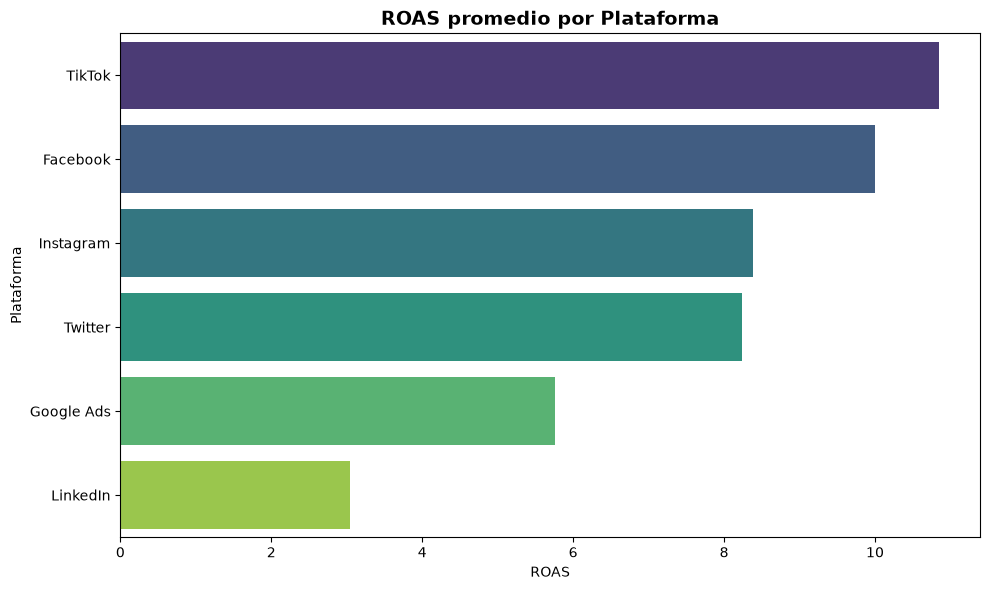

In [313]:
plt.figure(figsize=(10, 6))
platform_roas = df.groupby('platform')['ROAS'].mean().sort_values(ascending=False)
sns.barplot(x=platform_roas.values, y=platform_roas.index, palette='viridis')
plt.title('ROAS promedio por Plataforma', fontsize=14, fontweight='bold')
plt.xlabel('ROAS')
plt.ylabel('Plataforma')
plt.tight_layout()
plt.show()

C:\Users\jadt9\AppData\Local\Temp\ipykernel_3628\3270132046.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=obj_roas.values, y=obj_roas.index, palette='magma')


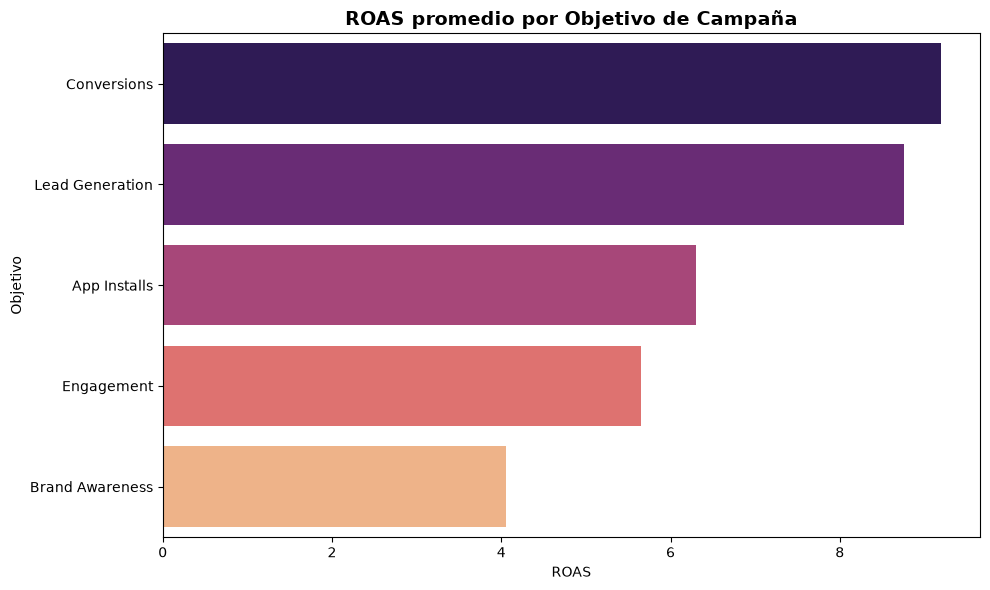

In [314]:
plt.figure(figsize=(10, 6))
obj_roas = df.groupby('campaign_objective')['ROAS'].mean().sort_values(ascending=False)
sns.barplot(x=obj_roas.values, y=obj_roas.index, palette='magma')
plt.title('ROAS promedio por Objetivo de Campaña', fontsize=14, fontweight='bold')
plt.xlabel('ROAS')
plt.ylabel('Objetivo')
plt.tight_layout()
plt.show()

C:\Users\jadt9\AppData\Local\Temp\ipykernel_3628\3072199533.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ind_roas.values, y=ind_roas.index, palette='coolwarm')


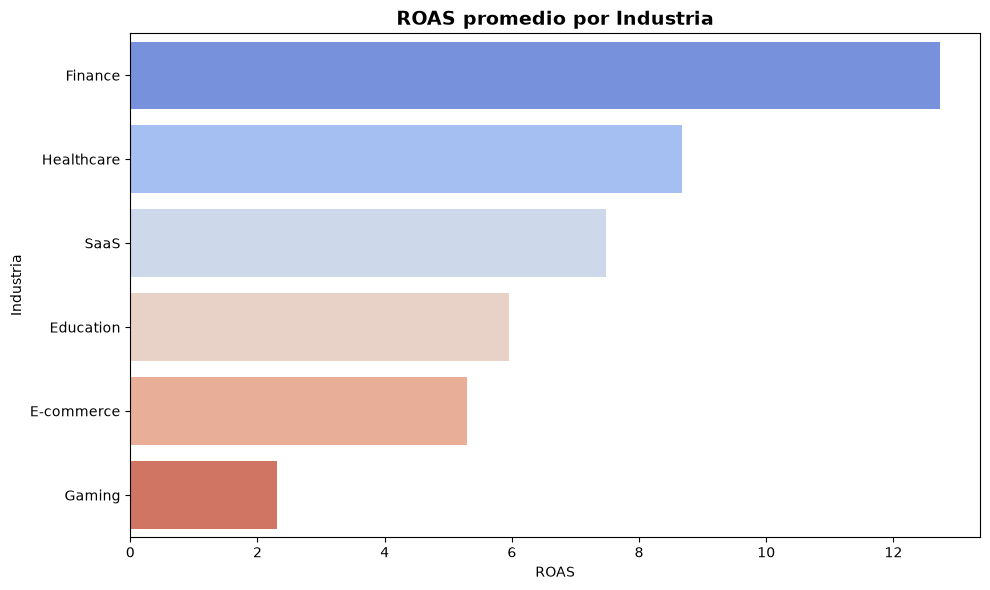

In [315]:
plt.figure(figsize=(10, 6))
ind_roas = df.groupby('industry_vertical')['ROAS'].mean().sort_values(ascending=False)
sns.barplot(x=ind_roas.values, y=ind_roas.index, palette='coolwarm')
plt.title('ROAS promedio por Industria', fontsize=14, fontweight='bold')
plt.xlabel('ROAS')
plt.ylabel('Industria')
plt.tight_layout()
plt.show()

In [316]:
# Top combinaciones Plataforma + Objetivo por ROAS
print("=== TOP 10 COMBINACIONES PLATAFORMA + OBJETIVO ===")

combo = df.groupby(['platform', 'campaign_objective']).agg({
    'ROAS': 'mean',
    'ad_spend': 'sum',
    'revenue': 'sum',
    'conversions': 'sum'
}).round(2)

combo = combo.sort_values('ROAS', ascending=False).head(10)
combo

=== TOP 10 COMBINACIONES PLATAFORMA + OBJETIVO ===


ROAS   ad_spend     revenue  conversions
platform  campaign_objective                                          
TikTok    Lead Generation    13.61  991617.28 12573028.17        32618
          Conversions        12.64  784048.13  9168317.84        22935
Facebook  Conversions        12.49 1803137.23 25579538.65        59615
Twitter   Conversions        12.20  868878.50 11533277.02        27215
Facebook  Lead Generation    11.52 2423733.60 29253852.25        67279
Instagram Lead Generation    10.72 1061454.65 10368630.07        24474
          App Installs        9.31  183876.25  4053320.03         4806
          Engagement          8.54  185446.84  1769347.82         3473
          Conversions         8.50  868414.90  7320478.54        16506
Twitter   Lead Generation     8.46  744721.92  5120171.00        13402

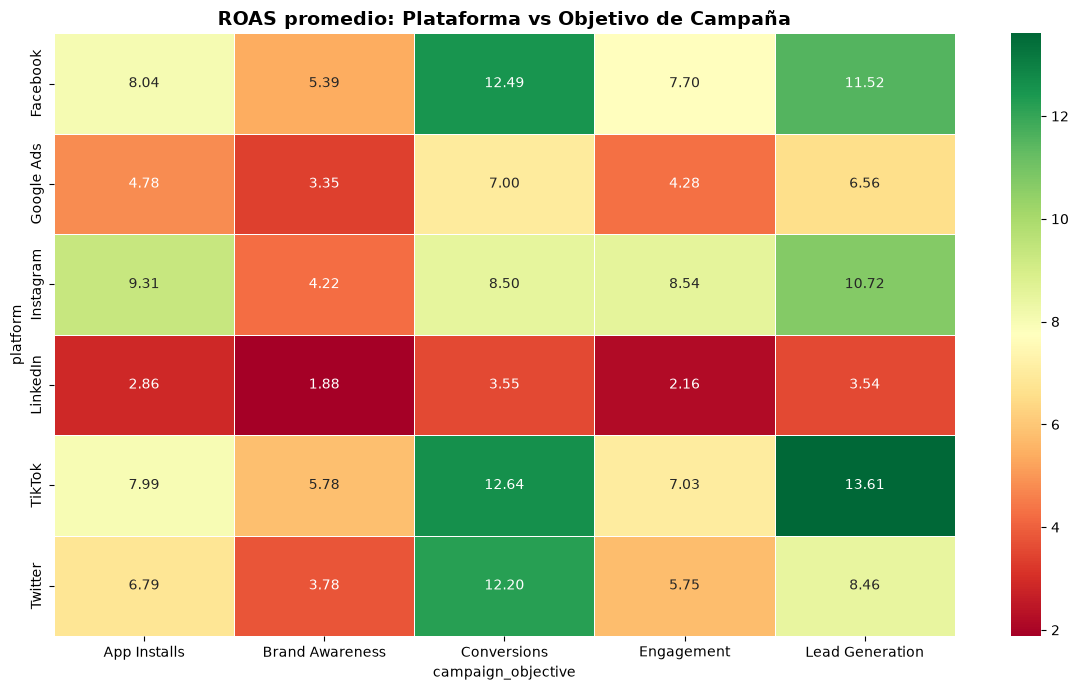

campaign_objective  App Installs  Brand Awareness  Conversions  Engagement  \
platform                                                                     
Facebook                    8.04             5.39        12.49        7.70   
Google Ads                  4.78             3.35         7.00        4.28   
Instagram                   9.31             4.22         8.50        8.54   
LinkedIn                    2.86             1.88         3.55        2.16   
TikTok                      7.99             5.78        12.64        7.03   
Twitter                     6.79             3.78        12.20        5.75   

campaign_objective  Lead Generation  
platform                             
Facebook                      11.52  
Google Ads                     6.56  
Instagram                     10.72  
LinkedIn                       3.54  
TikTok                        13.61  
Twitter                        8.46  


In [317]:
# Heatmap de ROAS: Plataforma vs Objetivo
pivot_roas = df.pivot_table(
    values='ROAS',
    index='platform',
    columns='campaign_objective',
    aggfunc='mean'
).round(2)

plt.figure(figsize=(12, 7))
sns.heatmap(pivot_roas, annot=True, cmap='RdYlGn', fmt='.2f', linewidths=0.5)
plt.title('ROAS promedio: Plataforma vs Objetivo de Campaña', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(pivot_roas)

In [318]:
# Seleccionamos las métricas numéricas más importantes
corr_cols = ['impressions', 'clicks', 'conversions', 'ad_spend', 'revenue', 
             'CTR', 'CPC', 'conversion_rate', 'CPA', 'ROAS']

# Verificamos cuáles existen
corr_cols = [col for col in corr_cols if col in df.columns]

# Matriz de correlación
corr_matrix = df[corr_cols].corr().round(2)
corr_matrix

,impressions,clicks,conversions,ad_spend,revenue,CTR,CPC,conversion_rate,CPA,ROAS
impressions,1.00,0.74,0.37,0.66,0.33,-0.07,-0.04,-0.02,0.06,-0.01
clicks,0.74,1.00,0.64,0.73,0.55,0.35,-0.11,0.09,-0.07,0.10
conversions,0.37,0.64,1.00,0.50,0.84,0.33,-0.04,0.47,-0.15,0.30
ad_spend,0.66,0.73,0.50,1.00,0.45,0.22,0.29,0.14,0.08,-0.04
revenue,0.33,0.55,0.84,0.45,1.00,0.27,-0.03,0.40,-0.13,0.42
CTR,-0.07,0.35,0.33,0.22,0.27,1.00,-0.13,0.32,-0.19,0.25
CPC,-0.04,-0.11,-0.04,0.29,-0.03,-0.13,1.00,0.11,0.39,-0.24
conversion_rate,-0.02,0.09,0.47,0.14,0.40,0.32,0.11,1.00,-0.30,0.51
CPA,0.06,-0.07,-0.15,0.08,-0.13,-0.19,0.39,-0.30,1.00,-0.23
ROAS,-0.01,0.10,0.30,-0.04,0.42,0.25,-0.24,0.51,-0.23,1.00


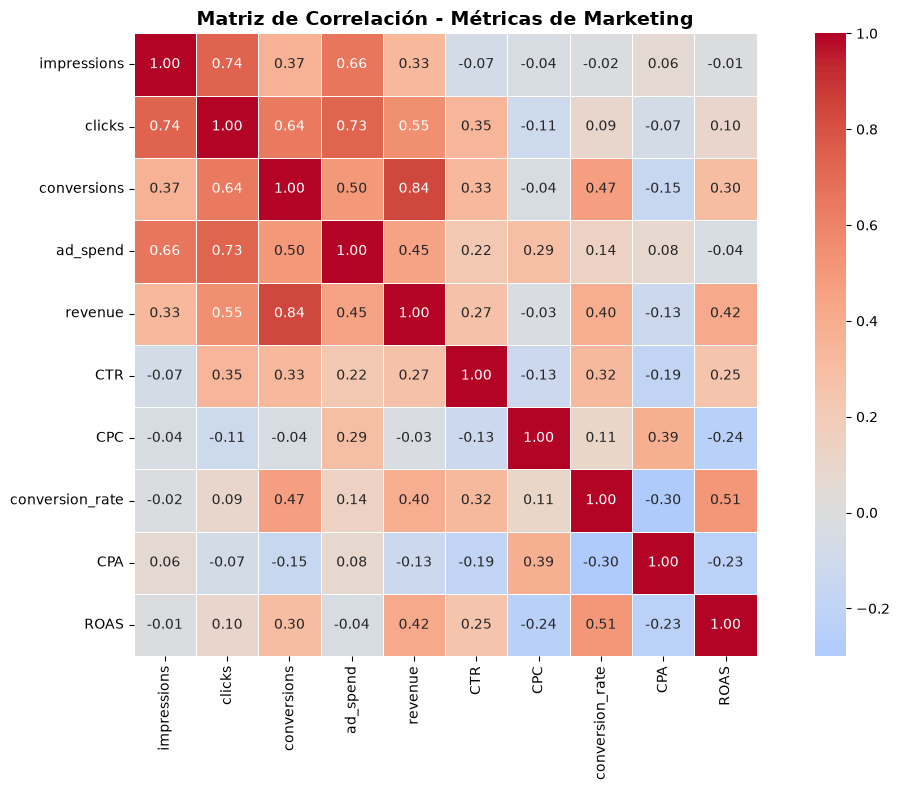

In [319]:
# Visualización de la correlación
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', linewidths=0.5, square=True)
plt.title('Matriz de Correlación - Métricas de Marketing', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Recomendaciones de Negocio

Con base en el análisis de 10.000 campañas digitales, se recomiendan las siguientes acciones:

### 1. Reasignación de Presupuesto
- **Aumentar** inversión en **TikTok** y **Facebook**, especialmente en campañas de **Lead Generation** y **Conversions** (ROAS entre 11.5 y 13.6).
- **Reducir** significativamente la inversión en **LinkedIn** y en campañas de **Brand Awareness**, que presentan el menor retorno.

### 2. Priorización por Industria
- Priorizar presupuestos en la industria de **Finance** (ROAS 12.72).
- Revisar creatividades y segmentación en **Gaming** (ROAS 2.31), ya que es la menos eficiente.

### 3. Enfoque Estratégico
- Las campañas orientadas a **Conversions** y **Lead Generation** generan consistentemente mejor ROAS que las de Awareness o Engagement.
- Google Ads tiene alto volumen pero menor eficiencia → optimizar o usar principalmente para objetivos de conversión.

### Impacto esperado
Una reasignación de presupuesto hacia las combinaciones de mayor ROAS puede mejorar significativamente la rentabilidad global de las campañas digitales.